# QuantumFidelityOptimization — figures

One cell per figure. Each cell displays its plot inline and also saves it as a PDF into `figures/`. Run the **Setup** cell first.

In [1]:
import csv
import glob
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import norm as sp_norm
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter1d
import seaborn as sns

%matplotlib inline

# ---------------------------------------------------------------------------
# Paths — locate the repo root by walking up from the notebook's directory
# until we find both data/ and src/ (works regardless of where Jupyter's
# working directory is set to).
# ---------------------------------------------------------------------------
def _find_repo_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (expected data/ and src/ nearby)")

REPO_ROOT = _find_repo_root(Path.cwd().resolve())
DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Shared APS-style formatting. Individual cells may locally override
# figure.figsize or other specifics to match their original script.
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}\usepackage{xcolor}",
})

def show_and_save(fig, filename):
    """Save a figure as a PDF in figures/. %matplotlib inline already displays
    every figure created during a cell's execution automatically, so this
    deliberately does not return fig — doing so would make it the cell's
    trailing expression and trigger a second, duplicate display."""
    out = FIGURE_DIR / filename
    fig.savefig(out)
    print(f"Saved -> {out}")


## Contour: 2D calibration landscapes (Q_infinity)

  Panel \textbf{a)}: varms_2 fcl/sideband — OK
  Panel \textbf{b)}: varms_2 sideband/rabi — OK
  Panel \textbf{c)}: varms_2 fcl/rabi — OK
Saved -> /home/patcaspu/QuantumFidelityOptimization/figures/contour_2ms.pdf


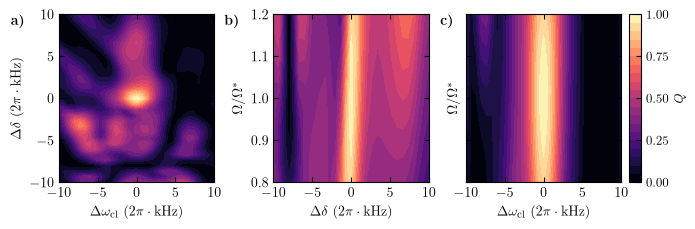

In [2]:
# ---------------------------------------------------------------------------
# APS formatting (matching plot_figure_ab_vertical.py)
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "figure.figsize": (6.75, 2.),
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
})
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
NUM_MS = int(os.environ.get("PLOT_NUM_MS", "2"))
N_LEVELS = 20
CMAP = "magma"

# Three axis pairs: (x_axis, y_axis) — left to right
# (a) x=Δω_cl, y=Δδ   (b) x=Δδ, y=Ω   (c) x=Δω_cl, y=Ω
AXIS_PAIRS = [
    ("fcl",      "sideband"),   # (a)
    ("sideband", "rabi"),       # (b)
    ("fcl",      "rabi"),       # (c)
]

PANEL_LABELS = [r"\textbf{a)}", r"\textbf{b)}", r"\textbf{c)}"]

# ---------------------------------------------------------------------------
# Axis helpers
# ---------------------------------------------------------------------------

def axis_column(axis):
    return {
        "rabi":     "rabi_ratio",
        "sideband": "sideband_2pi_khz",
        "fcl":      "fcl_2pi_khz",
        "phase":    "phase_pi",
    }[axis]


def axis_label(axis):
    return {
        "rabi":     r"$\Omega / \Omega^*$",
        "sideband": r"$\Delta \delta\ (2\pi \cdot \mathrm{kHz})$",
        "fcl":      r"$\Delta \omega_\mathrm{cl}\ (2\pi \cdot \mathrm{kHz})$",
        "phase":    r"$\Delta\phi / \pi$",
    }[axis]


FREQ_SCALE = 5.0   # stored units are 2pi kHz; multiply by 5 to get kHz


def axis_limits(axis):
    if axis in ("sideband", "fcl"):
        return (-10.0, 10.0)
    elif axis == "rabi":
        return (0.8, 1.2)
    elif axis == "phase":
        return (-0.5, 0.5)
    return None


def axis_ticks(axis):
    if axis == "rabi":
        return [0.8, 0.9, 1.0, 1.1, 1.2]
    elif axis in ("sideband", "fcl"):
        return [-10.0, -5.0, 0.0, 5.0, 10.0]
    elif axis == "phase":
        return [-0.5, -0.25, 0.0, 0.25, 0.5]
    return None

# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------

def read_heatmap(num_ms, axis_x, axis_y):
    """Load heatmap rows; tries both (axis_x, axis_y) and reversed file names."""
    for a, b in [(axis_x, axis_y), (axis_y, axis_x)]:
        path = DATA_DIR / f"varms_{num_ms}_heatmap_{a}_{b}.csv"
        if path.exists():
            rows = []
            with open(path, newline="") as f:
                for row in csv.DictReader(f):
                    if row.get("scan_kind", "heatmap") == "heatmap":
                        rows.append(row)
            if rows:
                return rows
    raise FileNotFoundError(
        f"Missing heatmap for {axis_x}/{axis_y} (tried both orderings)")


def make_grid(rows, axis_x, axis_y):
    """Build a regular 2D grid with axis_x on the x-axis and axis_y on the y-axis.
    Works regardless of which file ordering was found."""
    col_x  = axis_column(axis_x)
    col_y  = axis_column(axis_y)
    scale_x = FREQ_SCALE if axis_x in ("sideband", "fcl") else 1.0
    scale_y = FREQ_SCALE if axis_y in ("sideband", "fcl") else 1.0

    xs     = np.array([float(r[col_x]) * scale_x for r in rows])
    ys     = np.array([float(r[col_y]) * scale_y for r in rows])
    scores = np.array([float(r["score"])          for r in rows])

    x_uniq = np.sort(np.unique(xs))
    y_uniq = np.sort(np.unique(ys))

    Z = np.full((len(y_uniq), len(x_uniq)), np.nan)
    for x, y, s in zip(xs, ys, scores):
        ix = np.searchsorted(x_uniq, x)
        iy = np.searchsorted(y_uniq, y)
        Z[iy, ix] = s

    X, Y = np.meshgrid(x_uniq, y_uniq)
    return X, Y, Z

# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def draw_panel(ax, axis_x, axis_y, num_ms):
    rows = read_heatmap(num_ms, axis_x, axis_y)
    X, Y, Z = make_grid(rows, axis_x, axis_y)

    levels = np.linspace(0.0, 1.0, N_LEVELS + 1)
    cf = ax.contourf(X, Y, Z, levels=levels, cmap=CMAP)

    xlim = axis_limits(axis_x)
    ylim = axis_limits(axis_y)
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)

    xticks = axis_ticks(axis_x)
    yticks = axis_ticks(axis_y)
    if xticks:
        ax.set_xticks(xticks)
    if yticks:
        ax.set_yticks(yticks)

    ax.set_xlabel(axis_label(axis_x))
    ax.set_ylabel(axis_label(axis_y))
    ax.tick_params(which="both", direction="in", top=True, right=True)

    return cf

def build_figure():
    fig = plt.figure(figsize=(7.4, 2.4))

    # Manual axes positions [x0, y0, width, height] in figure fraction.
    # All three panels share identical width W so the layout is symmetric.
    y0, h = 0.22, 0.70   # bottom / height
    W     = 0.21          # panel width (figure fraction)
    # x0 positions:  (a) at 0.11 | gap 0.08 | (b) at 0.40 | gap 0.05 | (c) at 0.66
    # colorbar tight to (c): gap 0.01, width W*0.08
    ax_a    = fig.add_axes([0.11, y0, W,        h])
    ax_b    = fig.add_axes([0.40, y0, W,        h])
    ax_c    = fig.add_axes([0.66, y0, W,        h])
    cbar_ax = fig.add_axes([0.88, y0, W * 0.08, h])
    axes    = [ax_a, ax_b, ax_c]

    cf_last = None
    for i, (ax, (axis_x, axis_y), label) in enumerate(zip(axes, AXIS_PAIRS, PANEL_LABELS)):
        try:
            cf_last = draw_panel(ax, axis_x, axis_y, NUM_MS)

            # Hide y-tick labels only for panel (c); show for (a) and (b)
            if i == 2:
                ax.tick_params(labelleft=False)

            # Panel letter outside-left; panels with ytick labels need more offset
            x_off = -0.22 if i < 2 else -0.08
            ax.text(x_off, 1.0, label,
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=10, fontweight="bold", color="black", clip_on=False)

            print(f"  Panel {label}: varms_{NUM_MS} {axis_x}/{axis_y} — OK")
        except FileNotFoundError as e:
            print(f"  Skipping {label}: {e}", file=sys.stderr)
            ax.set_visible(False)

    if cf_last is not None:
        cbar = fig.colorbar(cf_last, cax=cbar_ax)
        cbar.set_label(r"$Q$", fontsize=9)
        cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
        cbar.ax.tick_params(labelsize=9)

    return fig
fig = build_figure()
show_and_save(fig, f"contour_{NUM_MS}ms.pdf")


## GP posterior slices + BO scatter (N=100 zoom)

Saved -> /home/patcaspu/QuantumFidelityOptimization/figures/figure_fcl_amp_n100_gpzoom.pdf


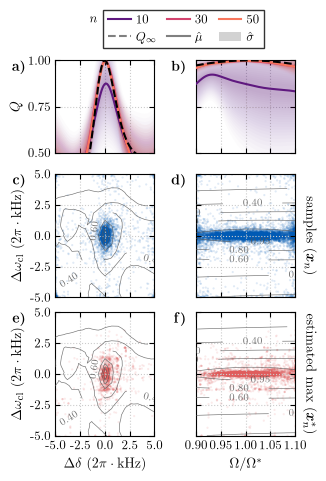

In [3]:
# ---------------------------------------------------------------------------
# APS formatting 
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "font.size":        9,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "lines.linewidth":  1.5,
    "xtick.direction":  "in",
    "ytick.direction":  "in",
})
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}\usepackage{xcolor}",
})

# Extract 3 distinct colors from the magma palette for the GP iterations
magma_cols = sns.color_palette("magma", n_colors=6).as_hex()
COLORS_GP = [magma_cols[1], magma_cols[3], magma_cols[4]]

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

GP_STEM         = "scale05_selectedN_gp_slices_iters10_30_50"
GP_SLICES_FILE  = DATA_DIR / "gp_slices" / f"{GP_STEM}.csv"
TRUE_SCORE_FILE = DATA_DIR / "score_cache" / "scale05_true_2ms_slices_freqspan10_grid201.csv"

def trace_dir_path(n_label):
    return DATA_DIR / f"traces_freqspan10_bound050_N{n_label}_nostop100_stream_100seeds"

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
N_FOCUS       = os.environ.get("PLOT_N_FOCUS", "100")
ITER_GPS      = [10, 30, 50]

FREQ_SPAN_KHZ  = 10.0   
AMP_SPAN_RATIO = 0.2    
BOUND_SCALE    = 0.5

# ---------------------------------------------------------------------------
# Axis helpers
# ---------------------------------------------------------------------------
AXES_1D  = ["fcl", "fsb", "amp"]

# Matches X-axes of Row 1 while cycling the remaining variable on Y
# Col 0: X=fcl (w_cl), Y=fsb (\delta)
# Col 1: X=fsb (\delta), Y=amp (\Omega)
# Col 2: X=amp (\Omega), Y=fcl (w_cl)
PAIRS_2D = [("fcl", "fsb"), ("fsb", "amp"), ("fcl", "amp")]

AXIS_LABELS = {
    "fcl": r"$\Delta \omega_\mathrm{cl}\ (2\pi \cdot \mathrm{kHz})$",
    "fsb": r"$\Delta \delta\ (2\pi \cdot \mathrm{kHz})$",
    "amp": r"$\Omega / \Omega^*$",
}
AXIS_LIMS = {
    "fcl": (-5.0, 5.0),
    "fsb": (-5.0, 5.0),
    "amp": (1.0 - BOUND_SCALE * AMP_SPAN_RATIO, 1.0 + BOUND_SCALE * AMP_SPAN_RATIO),
}
# Updated exactly to the requested tick marks
AXIS_TICKS = {
    "fcl": [-5.0, -2.5, 0.0, 2.5, 5.0],
    "fsb": [-5.0, -2.5, 0.0, 2.5, 5.0],
    "amp": [0.90, 0.95, 1.0, 1.05, 1.10],
}
_U_COL = {"fcl": "u1", "fsb": "u2", "amp": "u3"}

def u_to_phys(axis, u):
    if axis == "amp":
        return 1.0 + AMP_SPAN_RATIO * float(u)
    return FREQ_SPAN_KHZ * float(u)

def u_col(axis, data):
    return data[_U_COL[axis]]

TRUE_COLOR = "black"

# Set True to colour scatter points by their observed Q value (magma: dark=0 → yellow=1).
# When False the original flat colour is used.
USE_SCORE_COLOR = False

HEATMAP_MAP = {
    ("fcl", "fsb"): ("sideband_fcl",   "fcl_2pi_khz",      "sideband_2pi_khz"),
    ("fcl", "amp"): ("rabi_fcl",       "fcl_2pi_khz",      "rabi_ratio"),
    ("fsb", "amp"): ("rabi_sideband",  "sideband_2pi_khz", "rabi_ratio"),
}
TRUE_CONTOUR_LEVELS = [0.2, 0.4, 0.6, 0.8, 0.9, 0.95]

PANEL_LABELS = [[r"\textbf{a)}", r"\textbf{b)}"],
                [r"\textbf{c)}", r"\textbf{d)}"],
                [r"\textbf{e)}", r"\textbf{f)}"],]

# ---------------------------------------------------------------------------
# Data loading
# ---------------------------------------------------------------------------

def read_csv_file(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def load_true_score():
    rows = read_csv_file(TRUE_SCORE_FILE)
    out = {}
    for ax in AXES_1D:
        rs = sorted(
            [r for r in rows if r["axis"] == ax],
            key=lambda r: float(r["x_physical"]),
        )
        if ax == "amp":
            out[ax] = (np.array([1.0 + 0.2 * float(r["x_u"]) for r in rs]),
                       np.array([float(r["score"]) for r in rs]))
        else:
            out[ax] = (np.array([float(r["x_physical"]) for r in rs]),
                       np.array([float(r["score"]) for r in rs]))
    return out

def load_gp_slices():
    """Average the N_SEEDS_FOR_AVERAGE seeds' GP curves at each grid point,
    combining within-seed GP uncertainty and between-seed spread:
        sigma_total^2 = mean(sigma_i^2) + var(mu_i)
    """
    rows = read_csv_file(GP_SLICES_FILE)
    out = {ax: {} for ax in AXES_1D}
    for ax in AXES_1D:
        for it in ITER_GPS:
            rs = [r for r in rows
                  if r["N"] == N_FOCUS and r["axis"] == ax and int(r["iter"]) == it]
            if not rs:
                continue
            grouped = {}
            for r in rs:
                grouped.setdefault(float(r["x_u"]), []).append(r)
            xs = sorted(grouped)
            mus, sigmas = [], []
            for x_u in xs:
                mu_vals = np.array([float(r["mu"]) for r in grouped[x_u]])
                sig_vals = np.array([float(r["sigma"]) for r in grouped[x_u]])
                mus.append(mu_vals.mean())
                sigmas.append(np.sqrt(max((sig_vals ** 2).mean() + mu_vals.var(), 0.0)))
            if ax == "amp":
                x_phys = np.array([1.0 + 0.2 * x_u for x_u in xs])
            else:
                phys_by_u = {float(r["x_u"]): float(r["x_physical"]) for r in rs}
                x_phys = np.array([phys_by_u[x_u] for x_u in xs])
            out[ax][it] = (x_phys, np.array(mus), np.array(sigmas))
    return out

def load_contour_2d(ax_x, ax_y):
    """Return (x_phys, y_phys, score) for the 2D contour landscape, from the
    varms_2 heatmap CSVs. The heatmap's own scan already spans ±10 kHz
    (fcl/sideband) and [0.8, 1.2] (rabi_ratio = A/A_opt directly, no rescale
    needed) -- comfortably wider than the scale=0.5 window (±5 kHz, [0.9,1.1])
    these panels display, so no rescaling is needed either: just convert with
    the same factor plot_contour.py uses and let the existing axis limits
    (AXIS_LIMS, applied via set_xlim/set_ylim) crop the view to scale=0.5.
    """
    FREQ_SCALE = 5.0   # matches plot_contour.py: stored units are 2pi kHz
    for (kx, ky), (suffix, col_x, col_y) in HEATMAP_MAP.items():
        if {kx, ky} == {ax_x, ax_y}:
            path = DATA_DIR / f"varms_2_heatmap_{suffix}.csv"
            rows = [r for r in read_csv_file(path) if r.get("scan_kind", "heatmap") == "heatmap"]
            cx = col_x if ax_x == kx else col_y
            cy = col_y if ax_y == ky else col_x
            scale_x = FREQ_SCALE if cx in ("fcl_2pi_khz", "sideband_2pi_khz") else 1.0
            scale_y = FREQ_SCALE if cy in ("fcl_2pi_khz", "sideband_2pi_khz") else 1.0
            x = np.array([float(r[cx]) * scale_x for r in rows])
            y = np.array([float(r[cy]) * scale_y for r in rows])
            z = np.array([float(r["score"]) for r in rows])
            return x, y, z
    raise KeyError(f"No mapping for {ax_x}, {ax_y}")

def load_all_traces(n_label):
    d = trace_dir_path(n_label)
    paths = sorted(glob.glob(str(d / "trace_seed*_ucb.csv")))
    if not paths:
        raise FileNotFoundError(f"No traces in {d}")
    au1, au2, au3, ay = [], [], [], []
    ru1, ru2, ru3, ry = [], [], [], []
    for path in paths:
        for row in read_csv_file(path):
            au1.append(float(row["x_acq_u1"]))
            au2.append(float(row["x_acq_u2"]))
            au3.append(float(row["x_acq_u3"]))
            ru1.append(float(row["x_rec_u1"]))
            ru2.append(float(row["x_rec_u2"]))
            ru3.append(float(row["x_rec_u3"]))
            ay.append(float(row["y_acq"]))
            ry.append(float(row["q_det_rec"]))
    acq = {"u1": np.array(au1), "u2": np.array(au2), "u3": np.array(au3),
           "score": np.array(ay)}
    rec = {"u1": np.array(ru1), "u2": np.array(ru2), "u3": np.array(ru3),
           "score": np.array(ry)}
    return acq, rec

# ---------------------------------------------------------------------------
# Panel drawing
# ---------------------------------------------------------------------------

def _tick_setup(ax, ax_x, ax_y=None, hide_x=False):
    ax.set_xticks(AXIS_TICKS[ax_x])
    if ax_y:
        ax.set_yticks(AXIS_TICKS[ax_y])
    ax.tick_params(which="both", direction="in", top=True, right=True)
    if hide_x:
        ax.tick_params(labelbottom=False)

def _fuzzy_gradient_fill(ax, u, mu, sig, color, zorder=2):
    """50-layer fuzzy gradient fill identical to the reference script."""
    n_layers = 25 # Reduced from 50 to optimize rendering since it draws 3 times
    quantiles = np.linspace(0.05, 0.45, n_layers)
    base_alpha = 0.4 / n_layers
    for q in quantiles:
        z = sp_norm.ppf(1.0 - q)
        lower = np.clip(mu - z * sig, 0, 1)
        upper = np.clip(mu + z * sig, 0, 1)
        ax.fill_between(u, lower, upper, color=color, alpha=base_alpha,
                        linewidth=0, edgecolor="none", zorder=zorder)

def draw_1d_slice(ax, axis, true_data, gp_data, show_ylabel):
    # Add Gridlines
    ax.grid(True, which="major", color="#cccccc", linestyle=":", linewidth=0.8, zorder=0)

    x_tr, y_tr = true_data[axis]
    ax.plot(x_tr, y_tr, color=TRUE_COLOR, lw=1.5, ls="--", zorder=4)

    gp = gp_data.get(axis) if gp_data else None
    if gp is not None:
        for i, it in enumerate(ITER_GPS):
            if it in gp:
                x_gp, mu, sig = gp[it]
                ax.plot(x_gp, np.clip(mu, 0, 1), color=COLORS_GP[i], lw=1.5, zorder=3)
                # Apply fuzzy fill to all requested iterations
                _fuzzy_gradient_fill(ax, x_gp, mu, sig, COLORS_GP[i], zorder=2)

    ax.set_xlim(*AXIS_LIMS[axis])
    ax.set_ylim(0.5, 1.0)
    ax.set_yticks([0.5, 0.75, 1.0])

    if show_ylabel:
        ax.set_ylabel(r"$Q$")
    else:
        ax.tick_params(labelleft=False)
        
    _tick_setup(ax, axis, hide_x=True)
    
    if axis in ["fcl", "fsb"]:
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

def draw_2d_scatter(ax, data, ax_x, ax_y, col_idx, is_bottom_row, scatter_color, hide_ylabels=False, hide_yticklabels=False, contour_levels=None):
    # Add Gridlines
    ax.grid(True, which="major", color="#cccccc", linestyle=":", linewidth=0.8, zorder=0)

    xp = np.array([u_to_phys(ax_x, v) for v in u_col(ax_x, data)])
    yp = np.array([u_to_phys(ax_y, v) for v in u_col(ax_y, data)])
    xl, yl = AXIS_LIMS[ax_x], AXIS_LIMS[ax_y]

    if USE_SCORE_COLOR:
        scores = data.get("score", np.full(len(xp), np.nan))
        valid  = ~np.isnan(scores)
        if valid.any():
            ax.scatter(xp[valid], yp[valid], s=2.5,
                       c=scores[valid], cmap="magma", vmin=0.0, vmax=1.0,
                       alpha=0.25, edgecolors="none", zorder=1)
        if (~valid).any():
            ax.scatter(xp[~valid], yp[~valid], s=2.5,
                       color=scatter_color, alpha=0.12, edgecolors="none", zorder=1)
    else:
        ax.scatter(xp, yp, s=2.5, color=scatter_color, alpha=0.12, edgecolors="none", zorder=1)

    # Overlaid True score contour lines
    if contour_levels is None:
        contour_levels = TRUE_CONTOUR_LEVELS
    try:
        x_bg, y_bg, z_bg = load_contour_2d(ax_x, ax_y)
        cs = ax.tricontour(x_bg, y_bg, z_bg, levels=contour_levels,
                           colors="#555555", linewidths=0.45, linestyles="-", alpha=0.85, zorder=3)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")
    except (FileNotFoundError, KeyError) as e:
        print(f"  Heatmap contours unavailable for ({ax_x},{ax_y}): {e}", file=sys.stderr)

    ax.set_xlim(*xl)
    ax.set_ylim(*yl)
    
    if is_bottom_row:
        ax.set_xlabel(AXIS_LABELS[ax_x])
    else:
        ax.set_xlabel("")
        
    if hide_ylabels:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    else:
        ax.set_ylabel(AXIS_LABELS[ax_y])
        if hide_yticklabels:
            ax.tick_params(labelleft=False)
    hide_x = not is_bottom_row
    _tick_setup(ax, ax_x, ax_y, hide_x=hide_x)
    
    if ax_x in ["fcl", "fsb"]:
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    if ax_y in ["fcl", "fsb"]:
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

def add_panel_label(ax, label, x=-0.10):
    ax.text(x, 1.0, label, transform=ax.transAxes,
            ha="right", va="top", fontsize=10, fontweight="bold",
            clip_on=False, zorder=20)

# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def build_figure():
    true_data = load_true_score()
    gp_data   = load_gp_slices()
    acq_data, rec_data = load_all_traces(N_FOCUS)

    # 3×2 layout: row 1 shows fsb and amp slices; rows 2&3 show (fsb,fcl) and (amp,fcl)
    # so that δ and Ω land on the x-axis (transposed from original cols 0 & 2).
    ROW1_AXES   = ["fsb", "amp"]
    ROW23_PAIRS = [("fsb", "fcl"), ("amp", "fcl")]

    # Nested GridSpec: row 1 separated from the 2×2 block; rows 2&3 share the
    # same column width as row 1 (wspace=0.42 in both) and are flush vertically.
    fig_w = 3.375
    fig = plt.figure(figsize=(fig_w, 4.75))
    gs_outer = mgridspec.GridSpec(
        2, 1, figure=fig,
        left=0.17, right=0.88, top=0.87, bottom=0.08,
        height_ratios=[0.60, 1.7], hspace=0.12,
    )
    gs_r1  = mgridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0],
                                               wspace=0.42)
    gs_r23 = mgridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_outer[1],
                                               hspace=0.12, wspace=0.42)
    axes = np.array([
        [fig.add_subplot(gs_r1[0, 0]),   fig.add_subplot(gs_r1[0, 1])],
        [fig.add_subplot(gs_r23[0, 0]),  fig.add_subplot(gs_r23[0, 1])],
        [fig.add_subplot(gs_r23[1, 0]),  fig.add_subplot(gs_r23[1, 1])],
    ])

    # Row 1: 1D GP slices (fsb and amp only; rug marks omitted)
    for col, axis in enumerate(ROW1_AXES):
        ax = axes[0, col]
        draw_1d_slice(ax, axis, true_data, gp_data, show_ylabel=(col == 0))
        add_panel_label(ax, PANEL_LABELS[0][col], x=(-0.30 if col == 0 else -0.10))

    # Rows 2 & 3: 2D scatter with box (square) aspect ratio
    _levels_col1 = [l for l in TRUE_CONTOUR_LEVELS if l != 0.9]

    for col, (ax_x, ax_y) in enumerate(ROW23_PAIRS):
        hide_ylabels = (col != 0)
        levels = _levels_col1 if col == 1 else None

        # Row 2: acquisition samples
        ax = axes[1, col]
        draw_2d_scatter(ax, acq_data, ax_x, ax_y, col, is_bottom_row=False,
                        scatter_color="#005AB5", hide_ylabels=hide_ylabels,
                        contour_levels=levels)
        add_panel_label(ax, PANEL_LABELS[1][col], x=(-0.30 if col == 0 else -0.10))
        if col == 1:
            ax.text(1.08, 0.5, r"samples ($\bm{x}_{n}$)", transform=ax.transAxes,
                    rotation=-90, va="center", ha="left", fontsize=10, fontweight="bold")

        # Row 3: recommended best point
        ax = axes[2, col]
        draw_2d_scatter(ax, rec_data, ax_x, ax_y, col, is_bottom_row=True,
                        scatter_color="#E05C5C", hide_ylabels=hide_ylabels,
                        contour_levels=levels)
        add_panel_label(ax, PANEL_LABELS[2][col], x=(-0.30 if col == 0 else -0.10))
        if col == 1:
            ax.text(1.08, 0.5, r"estimated max ($\bm{x}_n^*$)", transform=ax.transAxes,
                    rotation=-90, va="center", ha="left", fontsize=10, fontweight="bold")

    # Two-row legend (ncol=3).  Matplotlib fills column-major (top-to-bottom per
    # column), so to display row-major we interleave: col0=[it0,Qdet], col1=[it1,mu],
    # col2=[it2,sigma] → handles order: it0, Qdet, it1, mu, it2, sigma.
    leg_handles = [
        Line2D([0],[0], color=COLORS_GP[0], lw=1.5, label=rf"${ITER_GPS[0]}$"),
        Line2D([0],[0], color="gray", lw=1.5, ls="--", label=r"$Q_\infty$"),
        Line2D([0],[0], color=COLORS_GP[1], lw=1.5, label=rf"${ITER_GPS[1]}$"),
        Line2D([0],[0], color="gray", lw=1.5,          label=r"$\hat{\mu}$"),
        Line2D([0],[0], color=COLORS_GP[2], lw=1.5, label=rf"${ITER_GPS[2]}$"),
        Patch(facecolor="gray", alpha=0.35, edgecolor="none",
              label=r"$\hat{\sigma}$"),
    ]
    leg = fig.legend(handles=leg_handles, loc="upper center", bbox_to_anchor=(0.55, 0.99),
                     ncol=3, frameon=True, edgecolor="black", fancybox=False,
                     fontsize=9, handlelength=1.8, handletextpad=0.4, columnspacing=0.9)
    fig.canvas.draw()
    leg_bb      = leg.get_window_extent()
    fig_w_px    = fig.get_figwidth()  * fig.dpi
    fig_h_px    = fig.get_figheight() * fig.dpi
    row1_y_frac = (leg_bb.y1 - leg_bb.height * 0.25) / fig_h_px
    left_x_frac = (leg_bb.x0 - 6) / fig_w_px
    fig.text(left_x_frac, row1_y_frac, r"$n$",
             fontsize=9, ha="right", va="center")

    return fig
fig = build_figure()
show_and_save(fig, f"figure_fcl_amp_n{N_FOCUS}_gpzoom.pdf")


## Panel A/B: scale trend + selected-N convergence

Panel A — scale trend:
  0.1: 100 traces, final median 1.69576e-07
  0.5: 100 traces, final median 3.72678e-07
  1.0: 77 traces, final median 6.60901e-06
Panel B — selected-N trend:
  N=$10^2$: 100 traces, final median 0.00119156
  N=$10^3$: 100 traces, final median 0.000418153
  N=$10^4$: 100 traces, final median 0.000147126
  N=$10^5$: 100 traces, final median 2.53675e-05
  N=$\infty$: 100 traces, final median 3.72678e-07
Saved -> /home/patcaspu/QuantumFidelityOptimization/figures/figure_ab_vertical.pdf


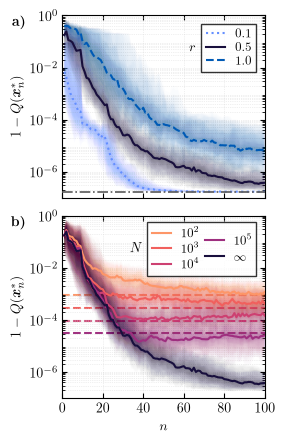

In [4]:
mpl.rcParams["figure.figsize"] = (3.375, 4.5)

# Ensure Homebrew binaries (dvipng, etc.) are visible to matplotlib



# ---------------------------------------------------------------------------
# APS Plot Formatting (PRX Intelligence / PR Applied)
# ---------------------------------------------------------------------------
# Single column width: 3.375 inches.
mpl.rcParams.update({
    "figure.figsize": (3.375, 4.5),  
    "font.family": "serif",          
    "mathtext.fontset": "cm",        
    "font.size": 10,                 
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,           
    "lines.linewidth": 1.5,          
})

# IMPORTANT: Added \usepackage{xcolor} so we can use \textcolor{white}
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}\usepackage{xcolor}",
})

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
MAX_ITER = 100
TRACE_INFLOOR = 1e-10
SCALE_INFLOOR = 1e-10
SCALE_DROP_FAILURES = True
SCALE_FAILURE_Q_THRESHOLD = 0.99

MODEL_DASH_EPS_INF = 4.6404956e-7
MODEL_DASH_A = 0.00891668
MODEL_DASH_ALPHA = 0.4947

# Palettes
# Generate 8 colors from magma to access distinct adjacent dark shades
magma_colors = sns.color_palette("magma", n_colors=8).as_hex()

SCALE_GROUPS = [
    {
        "label": "0.1",
        "color": "#648FFF",        # Aesthetic vibrant light blue
        "ls": ":",
        "dir": DATA_DIR / "traces_freqspan10_bound010_NInf_nostop100_stream_100seeds",
    },
    {
        "label": "0.5",
        "color": magma_colors[0],  # Absolute darkest (Matches N=Inf exactly)
        "ls": "-",
        "dir": DATA_DIR / "traces_freqspan10_bound050_NInf_nostop100_stream_100seeds",
    },
    {
        "label": "1.0",
        "color": "#005AB5",        # Aesthetic rich deep blue
        "ls": "--",
        "dir": DATA_DIR / "traces_freqspan10_bound100_NInf_nostop100_stream_100seeds",
    },
]

N_LABELS = ["100", "1000", "10000", "100000", "Inf"]
N_COLORS = {
    "100":    magma_colors[6], # Orange
    "1000":   magma_colors[5], # Pink/Orange
    "10000":  magma_colors[4], # Magenta/Purple
    "100000": magma_colors[3], # Medium-dark Purple
    "Inf":    magma_colors[0], # Absolute darkest
}
N_LEGENDS = {
    "100":    r"$10^2$",
    "1000":   r"$10^3$",
    "10000":  r"$10^4$",
    "100000": r"$10^5$",
    "Inf":    r"$\infty$",
}

# ---------------------------------------------------------------------------
# Data helpers
# ---------------------------------------------------------------------------

def trace_paths(directory: Path):
    directory = Path(directory)
    if not directory.is_dir():
        raise FileNotFoundError(f"Missing trace directory: {directory}")
    paths = sorted(glob.glob(str(directory / "trace_seed*_ucb.csv")))
    if not paths:
        raise FileNotFoundError(f"No trace CSVs found in {directory}")
    return paths

def read_trace(path: str):
    iters, qdets = [], []
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            iters.append(int(float(row["iter"])))
            qdets.append(float(np.clip(float(row["q_det_rec"]), 0.0, 1.0)))
    return {"iter": iters, "qdet": qdets}

def read_trace_group(directory: Path, drop_failures: bool = False):
    traces = [read_trace(p) for p in trace_paths(directory)]
    if drop_failures:
        traces = [t for t in traces if t["qdet"][-1] >= SCALE_FAILURE_Q_THRESHOLD]
        if not traces:
            raise ValueError(f"No traces left after failure filtering in {directory}")
    return traces

def forward_fill_infid(trace, max_iter: int = MAX_ITER, floor: float = TRACE_INFLOOR):
    values = np.empty(max_iter)
    cursor = 0
    last_q = trace["qdet"][0]
    for i, it in enumerate(range(1, max_iter + 1)):
        while cursor < len(trace["iter"]) and trace["iter"][cursor] <= it:
            last_q = trace["qdet"][cursor]
            cursor += 1
        values[i] = max(1.0 - last_q, floor)
    return values

def trace_matrix(traces, floor: float = TRACE_INFLOOR) -> np.ndarray:
    return np.vstack([forward_fill_infid(t, floor=floor) for t in traces])

def trace_dir_for_n(n_label: str) -> Path:
    return DATA_DIR / f"traces_freqspan10_bound050_N{n_label}_nostop100_stream_100seeds"

def model_dash_infid(n_label: str) -> float:
    return MODEL_DASH_EPS_INF + MODEL_DASH_A * float(n_label) ** (-MODEL_DASH_ALPHA)

def quantile_rows(matrix: np.ndarray, q: float) -> np.ndarray:
    return np.quantile(matrix, q, axis=0)

# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------

def _fuzzy_gradient_fill(ax, xs, mat, color, zorder=2, smooth_sigma=None):
    """Layered quantile shading."""
    n_layers   = 50
    quantiles  = np.linspace(0.05, 0.45, n_layers)
    base_alpha = 0.5 / n_layers
    for q in quantiles:
        lower = np.nanquantile(mat, q,       axis=0)
        upper = np.nanquantile(mat, 1.0 - q, axis=0)
        if smooth_sigma is not None:
            lower = gaussian_filter1d(lower, sigma=smooth_sigma)
            upper = gaussian_filter1d(upper, sigma=smooth_sigma)
        ax.fill_between(xs, lower, upper, color=color, alpha=base_alpha,
                        linewidth=0, edgecolor="none", zorder=zorder)

def style_log_axis(ax):
    ax.set_xlim(0, MAX_ITER)
    ax.set_ylim(1e-7, 1.0)
    ax.set_yscale("log")
    
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels(["0", "20", "40", "60", "80", "100"])
    
    locmaj = ticker.LogLocator(base=10.0, numticks=15)
    ax.yaxis.set_major_locator(locmaj)
    locmin = ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * .1, numticks=100)
    ax.yaxis.set_minor_locator(locmin)
    
    def custom_fmt(x, pos):
        if x > 0:
            exp = int(np.round(np.log10(x)))
            if exp in [0, -2, -4, -6]:
                return f"$10^{{{exp}}}$"
        return ""
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_fmt))
    
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(True, which="both", color="lightgray", linestyle=":", linewidth=0.5, alpha=0.7)


def draw_scale_trend(ax):
    xs = np.arange(1, MAX_ITER + 1)
    handles = {}
    ref_val = None   # final q50 of r=0.1 group

    for group in SCALE_GROUPS:
        try:
            traces = read_trace_group(group["dir"], drop_failures=SCALE_DROP_FAILURES)
        except FileNotFoundError as e:
            print(f"  Skipping scale group '{group['label']}': {e}", file=sys.stderr)
            continue

        mat = trace_matrix(traces, floor=SCALE_INFLOOR)
        q50 = quantile_rows(mat, 0.50)
        c = group["color"]
        ls = group["ls"]

        _fuzzy_gradient_fill(ax, xs, mat, color=c)
        line, = ax.plot(xs, q50, color=c, linestyle=ls, zorder=4)
        handles[group["label"]] = line

        if group["label"] == "0.1":
            ref_val = q50[79]   # median at iteration 80 (index 79)

        print(f"  {group['label']}: {mat.shape[0]} traces, final median {q50[-1]:.6g}")

    style_log_axis(ax)

    if ref_val is not None:
        ax.axhline(ref_val, color="0.35", ls="-.", lw=1.2, zorder=5)
    return handles


def draw_selected_n_trend(ax):
    xs = np.arange(1, MAX_ITER + 1)
    dash_refs = []
    handles = {}

    for n_label in N_LABELS:
        try:
            traces = read_trace_group(trace_dir_for_n(n_label))
        except FileNotFoundError as e:
            print(f"  Skipping N={n_label}: {e}", file=sys.stderr)
            continue

        mat = trace_matrix(traces, floor=TRACE_INFLOOR)
        q50 = quantile_rows(mat, 0.50)
        c = N_COLORS[n_label]

        _fuzzy_gradient_fill(ax, xs, mat, color=c)
        line, = ax.plot(xs, q50, color=c, zorder=4)
        handles[n_label] = line

        if n_label != "Inf":
            ref = max(model_dash_infid(n_label), TRACE_INFLOOR)
            dash_refs.append((ref, c))

        print(f"  N={N_LEGENDS[n_label]}: {mat.shape[0]} traces, final median {q50[-1]:.6g}")

    for ref, c in dash_refs:
        ax.axhline(ref, color=c, alpha=0.98, linestyle="--", linewidth=1.5, zorder=1)

    style_log_axis(ax)
    return handles

def add_side_title(ax, leg, text):
    """Dynamically places a text title to the immediate left of the legend box."""
    fig = ax.figure
    fig.canvas.draw()
    bbox = leg.get_window_extent().transformed(ax.transAxes.inverted())
    ax.text(bbox.x0 - 0.03, bbox.y0 + (bbox.height / 2), text, 
            transform=ax.transAxes, ha="right", va="center", fontsize=10)

# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def build_figure():
    fig, (ax_scale, ax_selected) = plt.subplots(
        2, 1,
        gridspec_kw={'height_ratios': [1, 1]},
        constrained_layout=False,
    )
    
    fig.subplots_adjust(left=0.25, right=0.85, top=0.95, bottom=0.1, hspace=0.1)

    # -----------------------------------------------------------------------
    # PANEL A: SCALE TREND
    # -----------------------------------------------------------------------
    print("Panel A — scale trend:")
    h_a_dict = draw_scale_trend(ax_scale)
    
    handles_a = []
    labels_a = []
    for g in SCALE_GROUPS:
        if g["label"] in h_a_dict:
            handles_a.append(h_a_dict[g["label"]])
            labels_a.append(g["label"])

    ax_scale.set_ylabel(r"$1 - Q(\bm{x}_n^*)$")
    ax_scale.set_xlabel("")
    ax_scale.set_xticklabels([])
    ax_scale.text(-0.18, 1.0, r"\textbf{a)}", transform=ax_scale.transAxes,
                  ha="right", va="top", fontsize=10, fontweight="bold", clip_on=False)
    ax_scale.set_ylim([1e-7, 1.0])
    ax_scale.set_yticks([1e-6, 1e-4, 1e-2, 1.0])

    # Legend A 
    leg_a = ax_scale.legend(handles_a, labels_a, loc="upper right", bbox_to_anchor=(0.99, 0.99), 
                            frameon=True, edgecolor="black", facecolor="white", 
                            fancybox=False, handlelength=1.5, labelspacing=0.2)
    add_side_title(ax_scale, leg_a, r"$r$")


    # -----------------------------------------------------------------------
    # PANEL B: SELECTED N TREND
    # -----------------------------------------------------------------------
    print("Panel B — selected-N trend:")
    h_b_dict = draw_selected_n_trend(ax_selected)
    
    # White line dummy handle to match the spacing flawlessly
    dummy_handle = Line2D([], [], color='white', linestyle='-', linewidth=1.5)
    
    # 1. Master Legend
    handles_b1 = [
        h_b_dict["100"], h_b_dict["1000"], h_b_dict["10000"],
        dummy_handle, dummy_handle, dummy_handle,
    ]
    
    # Put an actual string in the 4th slot so Matplotlib perfectly calculates the width
    labels_b1 = [
        r"$10^2$",
        r"$10^3$",
        r"$10^4$",
        r"$10^4$",   # <-- We will make this invisible below
        "",
        "",
    ]

    ax_selected.set_ylabel(r"$1 - Q(\bm{x}_n^*)$")
    ax_selected.set_xlabel(r"$n$")
    ax_selected.text(-0.18, 1.0, r"\textbf{b)}", transform=ax_selected.transAxes,
                     ha="right", va="top", fontsize=10, fontweight="bold", clip_on=False)
    ax_selected.set_ylim([1e-7, 1.0])
    ax_selected.set_yticks([1e-6, 1e-4, 1e-2, 1.0])
    
    # Draw the box and the 3 items on the left
    leg_b1 = ax_selected.legend(handles_b1, labels_b1, loc="center right", bbox_to_anchor=(0.99, 0.82),
                                ncol=2, frameon=True, edgecolor="black", facecolor="white",
                                fancybox=False, handlelength=1.5, labelspacing=0.2, columnspacing=0.5)
    ax_selected.add_artist(leg_b1)
    
    # --- THE MAGIC BULLET ---
    # Grab the text elements in the legend and make the 4th one (index 3) completely transparent
    leg_b1.get_texts()[3].set_alpha(0)
    
    # 2. Slave Legend (Vertically centered in the dummy space)
    handles_b2 = [h_b_dict["100000"], h_b_dict["Inf"]]
    labels_b2 = [r"$10^5$", r"$\infty$"]
    
    # Shifted slightly left so it perfectly overlays the transparent text
    leg_b2 = ax_selected.legend(handles_b2, labels_b2, loc="center right", bbox_to_anchor=(0.99, 0.82),
                                ncol=1, frameon=False, 
                                handlelength=1.5, labelspacing=0.4)
    
    # Add the N title outside the master box
    add_side_title(ax_selected, leg_b1, r"$N$")

    return fig
fig = build_figure()
show_and_save(fig, "figure_ab_vertical.pdf")


## 1D slices: Q_det vs GP surrogate

Saved -> /home/patcaspu/QuantumFidelityOptimization/figures/slices_plot.pdf


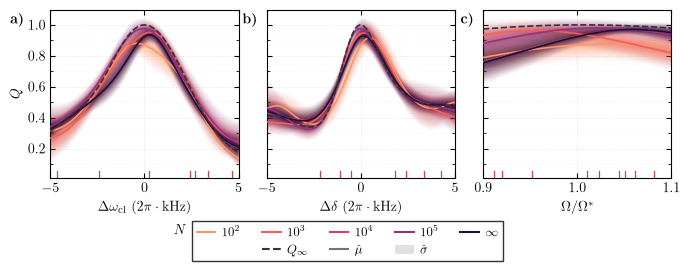

In [5]:
mpl.rcParams["figure.figsize"] = (6.75, 2.8)

# ═══════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# ═══════════════════════════════════════════════════════════════════════════════
SLICES_CSV  = os.path.join(DATA_DIR, "slices_output.csv")
METRICS_CSV = os.path.join(DATA_DIR, "gp_fit_quality_3d_2ms.csv")
NEAR_CSV    = os.path.join(DATA_DIR, "train_near_output.csv")
OUT_FILE    = os.path.join(FIGURE_DIR, "slices_plot.pdf")

N_PTS_SHOW   = 50
N_SHOTS_SHOW = None
# ═══════════════════════════════════════════════════════════════════════════════

AXES_ORDER  = ["fcl", "fsb", "amp"]

# Using formatting identical to the contour plots
AXIS_XLABEL = {
    "fcl": r"$\Delta\omega_\mathrm{cl}\ (2 \pi \cdot \mathrm{kHz})$",
    "fsb": r"$\Delta\delta\ (2 \pi \cdot \mathrm{kHz})$",
    "amp": r"$\Omega / \Omega^*$",
}

# Input spans for the transformed variables
def axis_limits(axis):
    if axis in ("fcl", "fsb"):
        return (-5.0, 5.0)
    elif axis == "amp":
        return (0.9, 1.1)
    return None

def axis_ticks(axis):
    if axis in ("fcl", "fsb"):
        return [-5.0, 0.0, 5.0]
    elif axis == "amp":
        return [0.9, 1.0, 1.1]
    return None

def transform_u(u_vals, ax_key):
    """Transforms the underlying u bounds [-0.5, 0.5] to physical dimensions."""
    if ax_key in ("fcl", "fsb"):
        return 10.0 * u_vals
    elif ax_key == "amp":
        return 1.0 + 0.2 * u_vals
    return u_vals

C_DET = "0.20"
C_RUG = "#cc2222"

# Magma palette extracted identically to figure_ab_vertical.py
_MAGMA_COLORS = sns.color_palette("magma", n_colors=8).as_hex()
N_COLORS = {
    100:    _MAGMA_COLORS[6],
    1000:   _MAGMA_COLORS[5],
    10000:  _MAGMA_COLORS[4],
    100000: _MAGMA_COLORS[3],
    float('inf'): _MAGMA_COLORS[0],
}

def apply_style():
    # APS Plot Formatting
    mpl.rcParams.update({
        "figure.figsize": (6.75, 2.8),   # Double column width
        "font.family": "serif",          
        "mathtext.fontset": "cm",        
        "font.size": 10,                 
        "axes.labelsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,           
        "lines.linewidth": 1.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })
    plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}\usepackage{xcolor}",
    })

def ns_label_no_N(ns):
    return r"$\infty$" if np.isinf(ns) else rf"$10^{{{int(np.log10(ns))}}}$"

def assign_colors(nshots_use):
    return {ns: N_COLORS.get(ns, "#000000") for ns in nshots_use}

def find_median_seeds(df_metrics, n_pts):
    sub = df_metrics[df_metrics["n_pts"] == n_pts]
    result = {}
    for ns, grp in sub.groupby("N_shots", sort=False):
        med = grp["rmse"].median()
        idx = (grp["rmse"] - med).abs().idxmin()
        result[ns] = (int(grp.loc[idx, "seed"]), float(grp.loc[idx, "rmse"]))
    return result

def _fuzzy_gradient_fill(ax, u, mu, sig, color, zorder=2):
    """Fuzzy 50-layer gradient fill replacing the solid blocks."""
    n_layers = 50
    quantiles = np.linspace(0.05, 0.45, n_layers)
    base_alpha = 0.5 / n_layers
    for q in quantiles:
        z = sp_norm.ppf(1.0 - q)
        lower = mu - z * sig
        upper = mu + z * sig
        ax.fill_between(u, lower, upper, color=color, alpha=base_alpha,
                        linewidth=0, edgecolor="none", zorder=zorder)

def draw_panel(ax, panel_df, near_df, ax_key, nshots_use, colors, first_col, panel_letter):
    # Q_det 
    ref = panel_df[panel_df["N_shots"] == nshots_use[0]].sort_values("u")
    if not ref.empty:
        u_trans = transform_u(ref["u"].values, ax_key)
        ax.plot(u_trans, ref["q_det"].values, color=C_DET, lw=1.2, ls="--", zorder=5)

    # GP surrogate
    for ns in nshots_use:
        d = panel_df[panel_df["N_shots"] == ns].sort_values("u")
        if d.empty:
            continue
        color = colors[ns]
        u_d_trans = transform_u(d["u"].values, ax_key)
        _fuzzy_gradient_fill(ax, u_d_trans, d["mu_gp"].values, d["sigma_gp"].values, color)
        ax.plot(u_d_trans, d["mu_gp"].values, color=color, lw=1.2, zorder=4)

    # Rug marks
    if near_df is not None and len(near_df) > 0:
        near_ax = near_df[near_df["axis"] == ax_key]
        for xu in np.unique(near_ax["u_proj"].values):
            xu_trans = transform_u(xu, ax_key)
            ax.axvline(xu_trans, ymin=0.0, ymax=0.04,
                       color=C_RUG, lw=0.9, alpha=0.85, zorder=7)

    ax.grid(True, which="major", color="#e0e0e0", linestyle=":", linewidth=0.6, zorder=0)
    ax.grid(True, which="minor", color="#eeeeee", linestyle=":", linewidth=0.35, zorder=0)
    ax.set_axisbelow(True)
    
    # Restrict to scaled limits
    lims = axis_limits(ax_key)
    if lims:
        ax.set_xlim(*lims)
    
    ticks = axis_ticks(ax_key)
    if ticks:
        ax.set_xticks(ticks)
        
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    
    # Tick formatting strictly pointing inwards
    ax.tick_params(axis="y", which="both", direction="in", right=True)
    ax.tick_params(axis="x", which="both", direction="in", top=True)

    ax.set_xlabel(AXIS_XLABEL.get(ax_key, ax_key))

    if first_col:
        ax.set_ylabel(r"$Q$")
    else:
        ax.tick_params(labelleft=False)

    # Add panel letter (a, b, c) matching contour plots
    x_letter = -0.14 if first_col else -0.05
    ax.text(x_letter, 0.98, panel_letter, transform=ax.transAxes,
            ha="right", va="top", fontsize=10, fontweight="bold")

def build_figure(n_pts=N_PTS_SHOW, nshots=N_SHOTS_SHOW, rug=True):
    df_slices  = pd.read_csv(SLICES_CSV)
    df_metrics = pd.read_csv(METRICS_CSV)

    median_seeds = find_median_seeds(df_metrics, n_pts)
    if not median_seeds:
        raise SystemExit(f"No metrics data for n_pts={n_pts}.")

    def _is_median(row):
        info = median_seeds.get(row["N_shots"])
        return info is not None and row["seed"] == info[0]

    sub = df_slices[df_slices["n_pts"] == n_pts].copy()
    sub = sub[sub.apply(_is_median, axis=1)]

    if sub.empty:
        raise SystemExit(f"No slice data for n_pts={n_pts}.")

    avail_nshots = sorted(sub["N_shots"].unique())
    nshots_use = [ns for ns in nshots if ns in avail_nshots] if nshots else avail_nshots
    colors = assign_colors(nshots_use)

    near_df = None
    if rug and os.path.isfile(NEAR_CSV):
        df_near = pd.read_csv(NEAR_CSV)
        near_df = df_near[(df_near["n_pts"] == n_pts) & df_near.apply(_is_median, axis=1)]

    # Figure Layout 
    fig, axes = plt.subplots(1, 3, constrained_layout=False, sharey=True)
    fig.subplots_adjust(left=0.06, right=0.98, top=0.95, bottom=0.35, wspace=0.15)

    panel_letters = [r"\textbf{a)}", r"\textbf{b)}", r"\textbf{c)}"]

    for ci, ax_key in enumerate(AXES_ORDER):
        ax = axes[ci]
        panel = sub[sub["axis"] == ax_key]
        if panel.empty:
            ax.set_visible(False)
            continue
        draw_panel(ax, panel, near_df, ax_key, nshots_use, colors,
                   first_col=(ci == 0), panel_letter=panel_letters[ci])

    # -----------------------------------------------------------------------
    # LEGEND CONSTRUCTION (Properly Interleaved for Column-Major Filling)
    # -----------------------------------------------------------------------
    dummy_handle = Line2D([], [], color='none')
    
    h_n = [Line2D([0], [0], color=colors[ns], lw=1.5) for ns in nshots_use]
    l_n = [ns_label_no_N(ns) for ns in nshots_use]

    h_qdet = Line2D([0], [0], color=C_DET, lw=1.5, ls="--")
    l_qdet = r"$Q_\infty$"

    h_mu = Line2D([0], [0], color="0.45", lw=1.5, ls="-")
    l_mu = r"$\hat{\mu}$"

    h_sig = Patch(facecolor="0.60", alpha=0.3, edgecolor="none")
    l_sig = r"$\hat{\sigma}$"

    if len(nshots_use) == 5:
        # Matplotlib populates legends COLUMN-BY-COLUMN. 
        # By alternating Top/Bottom components, we force 2 perfect rows.
        handles = [
            h_n[0], dummy_handle, # Col 1: 10^2 (top), blank (bottom)
            h_n[1], h_qdet,       # Col 2: 10^3 (top), Q_det (bottom)
            h_n[2], h_mu,         # Col 3: 10^4 (top), mu (bottom)
            h_n[3], h_sig,        # Col 4: 10^5 (top), sigma (bottom)
            h_n[4], dummy_handle  # Col 5: inf (top), blank (bottom)
        ]
        labels = [
            l_n[0], "", 
            l_n[1], l_qdet, 
            l_n[2], l_mu, 
            l_n[3], l_sig, 
            l_n[4], ""
        ]
        ncol_val = 5
    else:
        # Fallback 
        handles = h_n + [h_qdet, h_mu, h_sig]
        labels = l_n + [l_qdet, l_mu, l_sig]
        ncol_val = 4

    leg = fig.legend(
        handles=handles,
        labels=labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.03),
        ncol=ncol_val,
        fontsize=9,
        handlelength=1.5, 
        handletextpad=0.5,
        columnspacing=1.8,
        frameon=True,
        edgecolor="black",
        facecolor="white",
        fancybox=False
    )

    if len(nshots_use) == 5:
        # Hide the dummy texts completely to avoid bounding box artifacts
        texts = leg.get_texts()
        texts[1].set_alpha(0)  # Hides text under 10^2
        texts[9].set_alpha(0)  # Hides text under inf

    # Place the "N" label strictly outside the legend box aligned with the top row
    fig.canvas.draw()
    bbox = leg.get_window_extent().transformed(fig.transFigure.inverted())
    
    # In a 2-row layout, 0.75 targets the vertical center of the top row
    y_top_row = bbox.y0 + (bbox.y1 - bbox.y0) * 0.75
    fig.text(bbox.x0 - 0.01, y_top_row, r"$N$", ha="right", va="center", fontsize=10)

    return fig
fig = build_figure()
show_and_save(fig, "slices_plot.pdf")


## GP fit quality violins: RMSE

Saved -> /home/patcaspu/QuantumFidelityOptimization/figures/violin_rmse.pdf


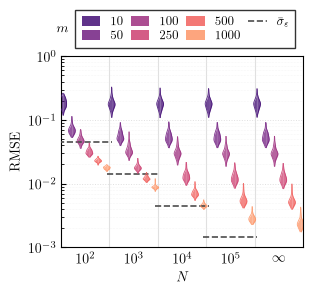

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# ═══════════════════════════════════════════════════════════════════════════════
CSV_FILE    = os.path.join(DATA_DIR, "gp_fit_quality_3d_2ms.csv")
# ═══════════════════════════════════════════════════════════════════════════════

def _magma_palette(n):
    """n evenly-spaced colours from magma (avoiding the very dark/light extremes)."""
    return sns.color_palette("magma", n_colors=n+2).as_hex()[1:-1]

def apply_style():
    # ---------------------------------------------------------------------------
    # APS Plot Formatting (PRX Intelligence / PR Applied)
    # ---------------------------------------------------------------------------
    mpl.rcParams.update({
        "figure.figsize": (3.375, 3),  
        "font.family": "serif",          
        "mathtext.fontset": "cm",        
        "font.size": 10,                 
        "axes.labelsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,           
        "lines.linewidth": 1.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
    })
    plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}\usepackage{xcolor}",
    })


def _kde_half(ax, values, x, side, half_width, color, alpha, log_scale, zorder):
    """Draw one half of a split violin on `ax`."""
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 4:
        med = np.median(vals) if len(vals) else np.nan
        if np.isfinite(med):
            ax.scatter([x], [med], color=color, s=20, zorder=zorder + 2)
        return

    if log_scale:
        v = np.log(vals[vals > 0])
        if len(v) < 4:
            return
        kde  = gaussian_kde(v, bw_method="silverman")
        lo, hi = v.min(), v.max()
        pad  = 0.08 * (hi - lo) if hi > lo else 0.1
        grid = np.linspace(lo - pad, hi + pad, 300)
        dens = kde(grid)
        ys   = np.exp(grid)
    else:
        kde  = gaussian_kde(vals, bw_method="silverman")
        lo, hi = vals.min(), vals.max()
        pad  = 0.05 * (hi - lo) if hi > lo else 1e-10
        grid = np.linspace(lo - pad, hi + pad, 300)
        dens = kde(grid)
        ys   = grid

    dens = dens / dens.max() * half_width

    if side == "left":
        ax.fill_betweenx(ys, x - dens, x,
                         color=color, alpha=alpha, linewidth=0, zorder=zorder)
        ax.plot(x - dens, ys, color=color, lw=0.6, alpha=0.9, zorder=zorder + 1)
    else:
        ax.fill_betweenx(ys, x, x + dens,
                         color=color, alpha=alpha, linewidth=0, zorder=zorder)
        ax.plot(x + dens, ys, color=color, lw=0.6, alpha=0.9, zorder=zorder + 1)

def _kde_full(ax, values, x, half_width, color, alpha, log_scale, zorder):
    """Full (both-halves) violin on a single axis."""
    _kde_half(ax, values, x, "left",  half_width, color, alpha, log_scale, zorder)
    _kde_half(ax, values, x, "right", half_width, color, alpha, log_scale, zorder)

def add_left_title(ax, leg, text):
    """Dynamically places a text title to the immediate left of the legend box."""
    fig = ax.figure
    fig.canvas.draw()
    bbox = leg.get_window_extent().transformed(ax.transAxes.inverted())
    ax.text(bbox.x0 - 0.02, bbox.y0 + (bbox.height / 2), text, 
            transform=ax.transAxes, ha="right", va="center", fontsize=10)

def add_slave_legend(ax, leg_master, handle, label):
    """Places a slave legend vertically centered in the far-right side of the master legend box."""
    fig = ax.figure
    fig.canvas.draw()
    # Grab the exact physical boundaries of the drawn Master Legend box
    bbox = leg_master.get_window_extent().transformed(ax.transAxes.inverted())
    
    # Place the slave legend in the vertical center of those boundaries
    leg_slave = ax.legend(handle, label, loc="center right", 
                          bbox_to_anchor=(bbox.x1 + 0.01, (bbox.y0 + bbox.y1) / 2),
                          fontsize=9, handlelength=1.5, frameon=False)
    ax.add_artist(leg_slave)

def _ax_style(ax, group_xs):
    """Common axis chrome for a single violin subplot."""
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(0.8)
    ax.tick_params(which="both", direction="in", top=True, right=False)
    ax.tick_params(axis="x", which="both", length=0)
    ax.yaxis.set_ticks_position("left")
    ax.grid(True, axis="y", which="major", color="#e0e0e0", linestyle=":", linewidth=0.7, zorder=0)
    ax.grid(True, axis="y", which="minor", color="#eeeeee", linestyle=":", linewidth=0.4, zorder=0)
    ax.set_axisbelow(True)
    for g in group_xs[1:]:
        ax.axvline(g - 0.5, color="0.88", lw=0.8, zorder=0)


def _fmt_n(n):
    if np.isinf(n):
        return r"$\infty$"
    exp = int(np.round(np.log10(n)))
    return rf"$10^{{{exp}}}$"


def _set_xaxis(ax, group_xs, nshots_vals):
    ax.set_xticks(group_xs)
    ax.set_xticklabels([_fmt_n(n) for n in nshots_vals])
    ax.set_xlabel(r"$N$")
    ax.set_xlim(-0.5, len(nshots_vals) - 0.5)


def _place_legend(fig, handles, **kw_extra):
    """Draw fig.legend without a title, then place 'm' as text to its left."""
    kw = dict(ncol=3, fontsize=9,
              handlelength=1.5, handleheight=0.8,
              borderpad=0.5, labelspacing=0.2, columnspacing=0.6,
              frameon=True, edgecolor="black", facecolor="white", fancybox=False)
    kw.update(kw_extra)
    leg = fig.legend(handles=handles, loc="upper center",
                     bbox_to_anchor=(0.58, 0.98),
                     bbox_transform=fig.transFigure, **kw)
    # Place "m" label to the left of the legend box in figure coordinates
    fig.canvas.draw()
    bb = leg.get_window_extent().transformed(fig.transFigure.inverted())
    fig.text(bb.x0 - 0.02, (bb.y0 + bb.y1) / 2, r"$m$",
             ha="right", va="center", fontsize=10)
    return leg


def _legend_npts(fig, npts_color, npts_vals):
    h = [Patch(facecolor=npts_color[n], alpha=0.85, label=rf"${n}$") for n in npts_vals]
    _place_legend(fig, h)


def build_figures(msse_variant="msse_gp"):
    df = pd.read_csv(CSV_FILE, encoding="utf-8")

    msse_col = "msse_gp" if msse_variant == "msse_gp" else "msse"

    npts_vals   = sorted(df["n_pts"].unique())
    nshots_vals = sorted(df["N_shots"].unique())
    colors      = _magma_palette(len(npts_vals))
    npts_color  = {n: colors[i] for i, n in enumerate(npts_vals)}

    n_v      = len(npts_vals)
    v_gap    = 0.18
    half_vw  = 0.07
    offsets  = np.linspace(-(n_v - 1) / 2, (n_v - 1) / 2, n_v) * v_gap
    group_xs = list(range(len(nshots_vals)))
    fig_w    = 3.375

    # ═══════════════════════════════════════════════════════════════════════
    # Figure 1 — RMSE  (with σ_ε dashed lines + sigma legend entry)
    # ═══════════════════════════════════════════════════════════════════════
    fig1, ax1 = plt.subplots(figsize=(fig_w, 3))
    fig1.tight_layout(rect=[0.10, 0.06, 1.0, 0.87])

    ax1.set_yscale("log");  ax1.set_ylim(1e-3, 1e0)
    _ax_style(ax1, group_xs)

    for g_idx, nshots in enumerate(nshots_vals):
        gc = group_xs[g_idx]
        # σ_ε dashed line per N_shots group
        s_vals = df.loc[df["N_shots"] == nshots, "mean_sigma_noise"].dropna().values
        if len(s_vals):
            xmin = gc + offsets[0]  - half_vw * 1.5
            xmax = gc + offsets[-1] + half_vw * 1.5
            ax1.hlines(np.median(s_vals), xmin, xmax,
                       color="0.3", linestyle="--", linewidth=1.2, zorder=3)
        for v_idx, npts in enumerate(npts_vals):
            xpos = gc + offsets[v_idx]
            mask = (df["N_shots"] == nshots) & (df["n_pts"] == npts)
            rmse_vals = df.loc[mask, "rmse"].dropna().values
            _kde_full(ax1, rmse_vals, xpos, half_vw, npts_color[npts],
                      alpha=0.75, log_scale=True, zorder=2)

    _set_xaxis(ax1, group_xs, nshots_vals)
    ax1.set_ylabel("RMSE")

    # Legend: n_pts patches + σ_ε dashed line
    h_npts = [Patch(facecolor=npts_color[n], alpha=0.85, label=rf"${n}$") for n in npts_vals]
    h_sigma = [Line2D([0], [0], color="0.3", ls="--", lw=1.2, label=r"$\bar{\sigma}_\varepsilon$")]
    _place_legend(fig1, h_npts + h_sigma,
                  ncol=min(4, len(h_npts) + len(h_sigma)))

    # ═══════════════════════════════════════════════════════════════════════
    # Figure 2 — MSSE  (no sigma lines, current legend)
    # ═══════════════════════════════════════════════════════════════════════
    fig2, ax2 = plt.subplots(figsize=(fig_w, 3))
    fig2.tight_layout(rect=[0.10, 0.06, 1.0, 0.87])

    ax2.set_yscale("log");  ax2.set_ylim(1e-1, 1e1)
    _ax_style(ax2, group_xs)
    ax2.axhline(1.0, color="0.45", lw=0.9, ls="--", alpha=0.6, zorder=1)

    for g_idx, nshots in enumerate(nshots_vals):
        gc = group_xs[g_idx]
        for v_idx, npts in enumerate(npts_vals):
            xpos = gc + offsets[v_idx]
            mask = (df["N_shots"] == nshots) & (df["n_pts"] == npts)
            msse_vals = df.loc[mask, msse_col].dropna().values
            _kde_full(ax2, msse_vals, xpos, half_vw, npts_color[npts],
                      alpha=0.75, log_scale=True, zorder=2)

    _set_xaxis(ax2, group_xs, nshots_vals)
    ax2.set_ylabel(r"$\mathrm{MSSE}$")

    _legend_npts(fig2, npts_color, npts_vals)

    return fig1, fig2
fig1, fig2 = build_figures(msse_variant="msse_gp")
plt.close(fig2)
show_and_save(fig1, "violin_rmse.pdf")


## GP fit quality violins: MSSE

Saved -> /home/patcaspu/QuantumFidelityOptimization/figures/violin_msse.pdf


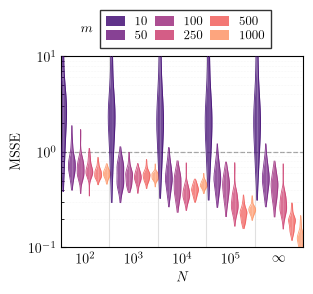

In [7]:
show_and_save(fig2, "violin_msse.pdf")
display(fig2)


## Optimal-input tables (median [5th, 95th] pct per group)

In [8]:
# ---------------------------------------------------------------------------
# Paths  (mirror plot_figure_ab_vertical.py)
# ---------------------------------------------------------------------------

SCALE_GROUPS = [
    {"label": "scale = 0.1",
     "dir": DATA_DIR / "traces_freqspan10_bound010_NInf_nostop100_stream_100seeds"},
    {"label": "scale = 0.5",
     "dir": DATA_DIR / "traces_freqspan10_bound050_NInf_nostop100_stream_100seeds"},
    {"label": "scale = 1.0",
     "dir": DATA_DIR / "traces_freqspan10_bound100_NInf_nostop100_stream_100seeds"},
]

N_GROUPS = [
    {"label": "N = 100",   "dir": DATA_DIR / "traces_freqspan10_bound050_N100_nostop100_stream_100seeds"},
    {"label": "N = 1000",  "dir": DATA_DIR / "traces_freqspan10_bound050_N1000_nostop100_stream_100seeds"},
    {"label": "N = 10k",   "dir": DATA_DIR / "traces_freqspan10_bound050_N10000_nostop100_stream_100seeds"},
    {"label": "N = 100k",  "dir": DATA_DIR / "traces_freqspan10_bound050_N100000_nostop100_stream_100seeds"},
    {"label": "N = Inf",   "dir": DATA_DIR / "traces_freqspan10_bound050_NInf_nostop100_stream_100seeds"},
]

INPUT_COLS  = ["x_rec_u1", "x_rec_u2", "x_rec_u3"]
INPUT_NAMES = [r"Δf_cl (kHz)", r"Δf_sb (kHz)", r"A/A_opt"]

# ---------------------------------------------------------------------------
# Data helpers
# ---------------------------------------------------------------------------

def last_row_inputs(path: str) -> np.ndarray:
    """Return x_rec_u1/u2/u3 from the last iteration row of one trace CSV."""
    best_iter = -1
    best_vals = None
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            it = int(float(row["iter"]))
            if it > best_iter:
                best_iter = it
                best_vals = np.array([float(row[c]) for c in INPUT_COLS])
    return best_vals


def group_stats(directory: Path):
    """
    Returns array of shape (n_seeds, 3) with the last-iteration inputs
    for every seed found in `directory`.
    """
    directory = Path(directory)
    if not directory.is_dir():
        return None
    paths = sorted(glob.glob(str(directory / "trace_seed*_ucb.csv")))
    if not paths:
        return None

    rows = []
    for p in paths:
        v = last_row_inputs(p)
        if v is not None:
            rows.append(v)
    if not rows:
        return None
    mat = np.array(rows)          # (n_seeds, 3)
    mat[:, 0] = 10.0 * mat[:, 0]          # u1 → Δf_cl (kHz)
    mat[:, 1] = 10.0 * mat[:, 1]          # u2 → Δf_sb (kHz)
    mat[:, 2] = 1.0 + 0.2 * mat[:, 2]    # u3 → A/A_opt
    return mat


# ---------------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------------

def fmt_sci(v):
    """Scientific notation with explicit +/- sign on the coefficient."""
    s = f"{v:.2e}"
    # ensure a space is reserved for positive values so columns align
    return f" {s}" if v >= 0 else s


def fmt(med, lo, hi):
    return f"{fmt_sci(med)}  [{fmt_sci(lo)}, {fmt_sci(hi)}]"


def print_table(groups, title):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")

    # Header
    col_w = 36
    header = f"{'Group':<18}" + "".join(f"{n:<{col_w}}" for n in INPUT_NAMES)
    print(header)
    print("-" * (18 + col_w * len(INPUT_NAMES)))

    for g in groups:
        mat = group_stats(g["dir"])
        if mat is None:
            print(f"{g['label']:<18}  [directory not found]")
            continue

        n = mat.shape[0]
        med = np.nanmedian(mat, axis=0)
        lo  = np.nanpercentile(mat, 5,  axis=0)
        hi  = np.nanpercentile(mat, 95, axis=0)

        row = f"{g['label']:<18}"
        for j in range(len(INPUT_COLS)):
            row += f"{fmt(med[j], lo[j], hi[j]):<{col_w+4}}"
        print(row + f"  (n={n})")

    print()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
print_table(SCALE_GROUPS, "Scale groups  (N = Inf,  scale = 0.1 / 0.5 / 1.0)")
print_table(N_GROUPS,     "Shot-count groups  (scale = 0.5,  N = 100 … Inf)")



  Scale groups  (N = Inf,  scale = 0.1 / 0.5 / 1.0)
Group             Δf_cl (kHz)                         Δf_sb (kHz)                         A/A_opt                             
------------------------------------------------------------------------------------------------------------------------------
scale = 0.1       -3.02e-06  [-6.50e-05,  5.80e-05]       -7.67e-03  [-7.75e-03, -7.57e-03]        1.00e+00  [ 1.00e+00,  1.00e+00]         (n=100)
scale = 0.5       -1.41e-05  [-9.08e-04,  8.31e-04]       -7.68e-03  [-8.91e-03, -6.39e-03]        1.00e+00  [ 1.00e+00,  1.01e+00]         (n=100)
scale = 1.0       -9.60e-04  [-9.91e+00,  3.14e-03]       -6.16e-03  [-3.42e+00,  9.00e+00]        1.01e+00  [ 1.00e+00,  1.20e+00]         (n=100)


  Shot-count groups  (scale = 0.5,  N = 100 … Inf)
Group             Δf_cl (kHz)                         Δf_sb (kHz)                         A/A_opt                             
---------------------------------------------------------------------